In [1]:
import numpy as np #lineer algebra
import pandas as pd #data processing
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
df=pd.read_csv('Social_Network_Ads.csv')

In [4]:
df


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [5]:
df = df.iloc[:,2:]

In [6]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [7]:
df.sample(5)

,Age,EstimatedSalary,Purchased
22,48,41000,1
338,38,55000,0
242,50,88000,1
230,35,147000,1
210,48,96000,1


**Train test split**
-> gives(X,y,testsize,random_state->gives same rows each time)

In [8]:
from sklearn.model_selection import train_test_split

In [10]:
X_train,X_test,y_train,y_test = train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)

In [11]:
X_train.shape,X_test.shape

((280, 2), (120, 2))

**StandardScaler**

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [13]:
#transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler.mean_

**X_train_scaled becomes a NumPy array, not a DataFrame. So , we have to convert it into dataframe.**

In [21]:
X_train_scaled = pd.DataFrame(X_train_scaled , columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled , columns=X_test.columns)
#Take the scaled array and create a DataFrame from it. Use the original column names.

In [23]:
np.round(X_train_scaled.describe(),1) #np.round(..., 1)-->Rounds all numbers to 1 decimal place.

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


**Before and After Scaling**

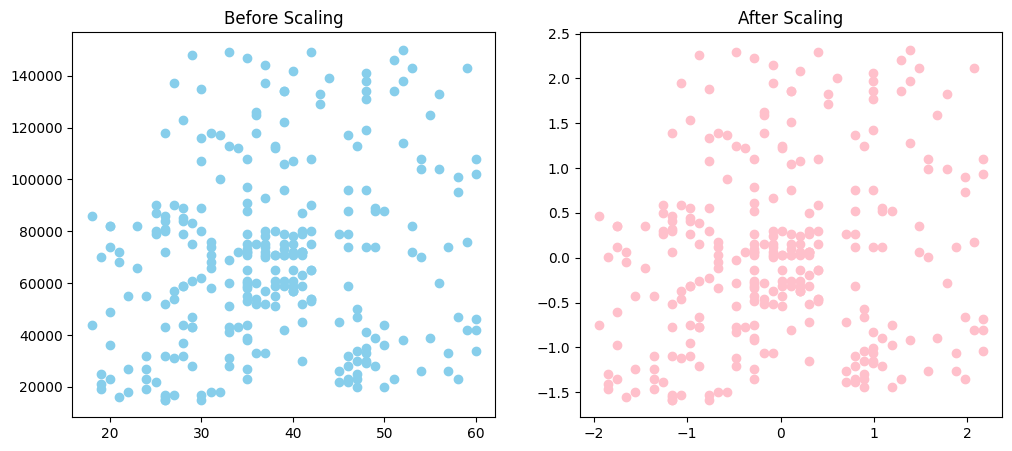

In [28]:
fig, (ax1,ax2) = plt.subplots(ncols=2 , figsize=(12,5)) #--> 2 cols with default 1 row and (width,height) in inches

ax1.scatter(X_train['Age'],X_train['EstimatedSalary'], color='skyblue')
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'] , color='Pink')
ax2.set_title("After Scaling")

plt.show()
            

**Scaling doesnot affect the decision tree algo but it affects the logistic regression.**

**Outliers have affect on scaling but still act as outliers after scaling , so we have to explicitly take care of outliers**

**When to use standarization:(generally with the algo consisting of calculation distances)
**1. Kmeans**
2. K nearest neighbours
3. PCA->Principal Component Analysis
4. Artificial Neural Network
5. Gradient Descent**

**We donot scale in decision trees, Random forest algo , XG boost etc**